Dataset import

/images -> raw images of the dataset

/fixations -> binary map. 1 where users pointed at saliency point

/maps -> continous version of the fixation, values from 0 to 255, interpolated from fixations

Note: the same 12 long id identifies a sample across images, fixations and maps

!pip install kaggle
!kaggle datasets download -d roshan401/salicon \
  -p ./datasets/salicon --unzip

./datasets/salicon 3 0
./datasets/salicon/fixations 3 0
./datasets/salicon/fixations/train 0 10000
./datasets/salicon/fixations/val 0 5000
./datasets/salicon/fixations/test 0 5000
./datasets/salicon/images 1 0
./datasets/salicon/images/images 3 0
./datasets/salicon/images/images/train 0 10000
./datasets/salicon/images/images/val 0 5000
./datasets/salicon/images/images/test 0 5000
./datasets/salicon/maps 2 0
./datasets/salicon/maps/train 0 10000
./datasets/salicon/maps/val 0 5000
Image size : (640, 480)
Map size : (640, 480)
RGB
L
uint8 0 255


Text(0.5, 1.0, 'Saliency')

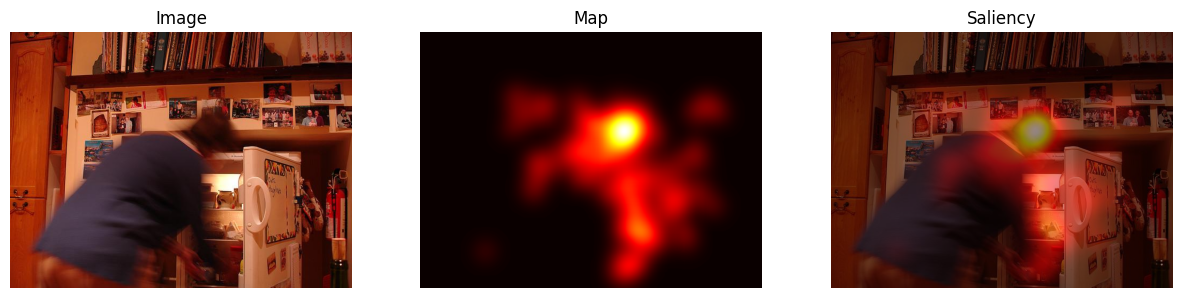

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from matplotlib import image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
from torch import nn
from torchinfo import summary
from torch.optim import Adam

seed = np.random.seed(42)
random.seed(42)

root = './datasets/salicon'
os.walk(root)

for dirpath, dirnames, filenames in os.walk(root):
    print(dirpath, len(dirnames), len(filenames))

TRAIN_DIR = Path(root) / "images/images"
FIX_DIR = Path(root) / "fixations"
MAP_DIR = Path(root) / "maps"

img1 = Image.open(root + '/images/images/train/COCO_train2014_000000096723.jpg')
img2 = Image.open(root + '/maps/train/COCO_train2014_000000096723.png')

print(f"Image size : {img1.size}")
print(f"Map size : {img2.size}")
print(img1.mode)
print(img2.mode)

c = np.array(img2)
print(c.dtype, c.min(), c.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1); axes[0].axis("Off"); axes[0].set_title("Image")

axes[1].imshow(img2, cmap="hot"); axes[1].axis("Off"); axes[1].set_title("Map")

axes[2].imshow(img1); axes[2].imshow(img2, cmap="hot", alpha=0.5); axes[2].axis("Off"); axes[2].set_title("Saliency")


In [2]:
#Prepare training data paths
image_paths_train = []
map_paths_train = []
stem_dict = {}

for f in os.listdir(MAP_DIR / 'train'):
  stem = Path(f).stem
  stem_dict[stem] = f

for f in os.listdir(TRAIN_DIR / 'train'):
  stem = Path(f).stem
  if stem in stem_dict:
    image_paths_train.append(TRAIN_DIR / 'train'/ f)
    map_paths_train.append(MAP_DIR /'train'/ stem_dict[stem])

print(f"Train size: {len(image_paths_train)}")
print(f"Train size: {len(map_paths_train)}")

#Prepare val/test
image_paths_val_full = []
map_paths_val_full = []
stem_dict = {}

for f in os.listdir(MAP_DIR / 'val'):
  stem = Path(f).stem
  stem_dict[stem] = f

for f in os.listdir(TRAIN_DIR / 'val'):
  stem = Path(f).stem
  if stem in stem_dict:
    image_paths_val_full.append(TRAIN_DIR / 'val'/ f)
    map_paths_val_full.append(MAP_DIR / 'val'/ stem_dict[stem])

idx = list(range(len(image_paths_val_full)))
random.shuffle(idx)

val_idx, test_idx = idx[:3500], idx[3500:]

image_paths_val = [image_paths_val_full[i] for i in val_idx]
image_paths_test = [image_paths_val_full[i] for i in test_idx]
map_paths_val = [map_paths_val_full[i] for i in val_idx]
map_paths_test = [map_paths_val_full[i] for i in test_idx]

print(f"Val size: {len(image_paths_val)}")
print(f"Test size: {len(image_paths_test)}")

Train size: 10000
Train size: 10000
Val size: 3500
Test size: 1500


In [3]:
class ImageDataset(Dataset):

  def __init__(self, image_paths, map_paths, image_size=(256, 256)):

    if len(image_paths) != len(map_paths):
      raise ValueError("Number of images and maps must be the same")

    self.image_paths = image_paths
    self.map_paths = map_paths
    self.image_size = image_size

    self.image_transform = Compose([
        Resize(self.image_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    self.map_transform = Compose([
        Resize(self.image_size),
        ToTensor()
    ])

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, index):
    image_path = self.image_paths[index]
    map_path = self.map_paths[index]

    image = Image.open(image_path).convert("RGB")
    sal = Image.open(map_path).convert("L")

    return(self.image_transform(image), self.map_transform(sal))


ATTENZIONE: IN LOCALE SU GPU METTI pin_memory = True


In [4]:
train_ds = ImageDataset(image_paths_train, map_paths_train)
val_ds = ImageDataset(image_paths_val, map_paths_val)
test_ds = ImageDataset(image_paths_test, map_paths_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True, drop_last=False)

#test:
imgs, sals = next(iter(train_loader))
print(imgs.shape, imgs.dtype)
print(sals.shape, sals.dtype)
print(imgs.min().item(), imgs.max().item())  # dopo Normalize, NON in [0,1]
print(sals.min().item(), sals.max().item())  # in [0,1]

torch.Size([16, 3, 256, 256]) torch.float32
torch.Size([16, 1, 256, 256]) torch.float32
-2.1179039478302 2.640000104904175
0.0 1.0


In [5]:
backbone = models.resnet18()

for name, child in backbone.named_children():
    print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


In [6]:
class encoder(nn.Module):

  def __init__(self):
    super().__init__()

    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    self.stem = nn.Sequential(
        backbone.conv1,
        backbone.bn1,
        backbone.relu,
        backbone.maxpool
    )
    self.layer1 = backbone.layer1
    self.layer2 = backbone.layer2
    self.layer3 = backbone.layer3
    self.layer4 = backbone.layer4

    #ignore last 2 layers of resnet

  def forward(self, x):
    x = self.stem(x)
    c1 = self.layer1(x)
    c2 = self.layer2(c1)
    c3 = self.layer3(c2)
    c4 = self.layer4(c3)
    return c1, c2, c3, c4

In [7]:
class decoder(nn.Module):

  def __init__(self):

    super().__init__()

    self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
    self.conv1 = nn.Conv2d(in_channels=768, out_channels=256, kernel_size=3, stride=1, padding=1)
    self.bn1 = nn.BatchNorm2d(256)

    self.conv2 = nn.Conv2d(in_channels=384, out_channels=128, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(128)

    self.conv3 = nn.Conv2d(in_channels=192, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.bn3 = nn.BatchNorm2d(64)

    self.conv4 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.bn4 = nn.BatchNorm2d(32)

    self.conv5 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1)

  def forward(self, c1, c2, c3, c4):

    x = self.up(c4)
    x = torch.cat([x, c3], dim=1)
    x = self.conv1(x)
    x = self.bn1(x)
    x = torch.relu(x)

    x = self.up(x)
    x = torch.cat([x, c2], dim=1)
    x = self.conv2(x)
    x = self.bn2(x)
    x = torch.relu(x)

    x = self.up(x)
    x = torch.cat([x, c1], dim=1)
    x = self.conv3(x)
    x = self.bn3(x)
    x = torch.relu(x)

    x = self.up(x)
    x = self.conv4(x)
    x = self.bn4(x)
    x = torch.relu(x)

    x = self.up(x)
    x = self.conv5(x)

    return x

#sanity check
dummy = encoder()
z = torch.zeros((2, 3, 256, 256))
c1, c2, c3, c4 = dummy.forward(z)
print(c1.shape, c2.shape, c3.shape, c4.shape)
f = decoder()
f.forward(c1, c2, c3, c4)

torch.Size([2, 64, 64, 64]) torch.Size([2, 128, 32, 32]) torch.Size([2, 256, 16, 16]) torch.Size([2, 512, 8, 8])


tensor([[[[-0.1484, -0.2901, -0.2254,  ..., -0.0949, -0.0695,  0.3057],
          [-0.1210, -0.2221, -0.1472,  ..., -0.1329, -0.2650, -0.1531],
          [-0.1284, -0.1371, -0.0217,  ..., -0.2212, -0.2937, -0.1302],
          ...,
          [-0.0636, -0.0222,  0.0164,  ..., -0.3007, -0.3322, -0.2916],
          [-0.0122,  0.1279,  0.2178,  ..., -0.3318, -0.3824, -0.3334],
          [ 0.0203,  0.0400,  0.0280,  ...,  0.0859,  0.0100, -0.3192]]],


        [[[-0.1484, -0.2901, -0.2254,  ..., -0.0949, -0.0695,  0.3057],
          [-0.1210, -0.2221, -0.1472,  ..., -0.1329, -0.2650, -0.1531],
          [-0.1284, -0.1371, -0.0217,  ..., -0.2212, -0.2937, -0.1302],
          ...,
          [-0.0636, -0.0222,  0.0164,  ..., -0.3007, -0.3322, -0.2916],
          [-0.0122,  0.1279,  0.2178,  ..., -0.3318, -0.3824, -0.3334],
          [ 0.0203,  0.0400,  0.0280,  ...,  0.0859,  0.0100, -0.3192]]]],
       grad_fn=<ConvolutionBackward0>)

In [12]:
image_encoder = encoder()
image_decoder = decoder()

loss_fn = torch.nn.BCEWithLogitsLoss()

lr = 1e-4

params_to_optimize = [
    {'params': image_encoder.parameters()},
    {'params': image_decoder.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-5)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

image_encoder.to(device)
image_decoder.to(device)

Selected device: cuda


decoder(
  (up): Upsample(scale_factor=2.0, mode='bilinear')
  (conv1): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [13]:
# Training function
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
    encoder.train()
    decoder.train()
    losses = []
    for image_batch, image_map_batch in dataloader:
        
        image_batch = image_batch.to(device)
        
        image_map_batch = image_map_batch.to(device)
        
        c1, c2, c3, c4 = encoder(image_batch)

        decoded_data = decoder(c1, c2, c3, c4)

        loss = loss_fn(decoded_data, image_map_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.detach().cpu().numpy())
    losses = np.mean(losses)
    return losses

In [14]:
def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    encoder.eval()
    decoder.eval()
    val_losses = []
    
    with torch.no_grad():
        for image_batch, image_map_batch in dataloader:
            image_batch = image_batch.to(device)
            image_map_batch = image_map_batch.to(device)
            
            c1, c2, c3, c4 = encoder(image_batch)
            decoded_data = decoder(c1, c2, c3, c4)

            loss = loss_fn(decoded_data, image_map_batch)
            val_losses.append(loss.item())

    return np.mean(val_losses)

EPOCH 1/50
TRAIN - EPOCH 1/50 - loss: 0.2816198170185089
VALIDATION - EPOCH 1/50 - loss: 0.23704011289224233



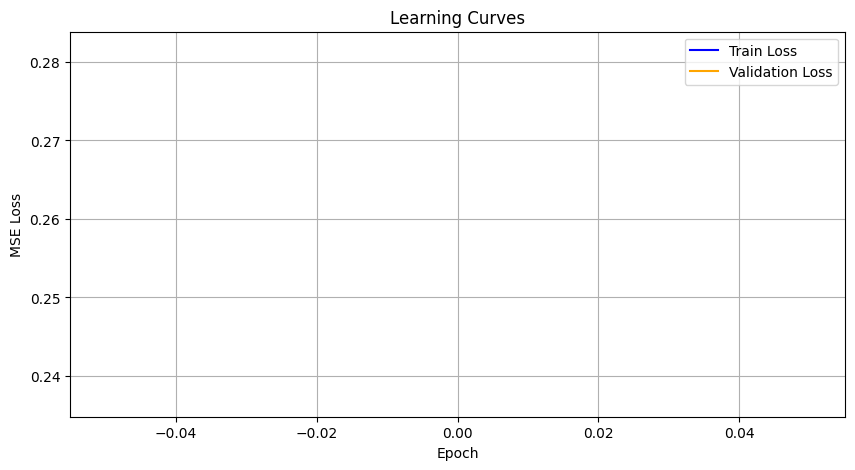

EPOCH 2/50
TRAIN - EPOCH 2/50 - loss: 0.21435043215751648
VALIDATION - EPOCH 2/50 - loss: 0.2319655326539523



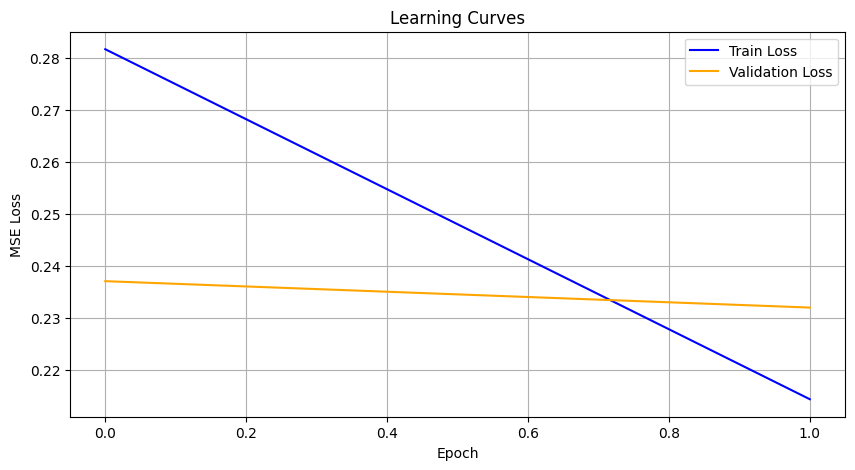

EPOCH 3/50
TRAIN - EPOCH 3/50 - loss: 0.20669926702976227
VALIDATION - EPOCH 3/50 - loss: 0.23161997921662789



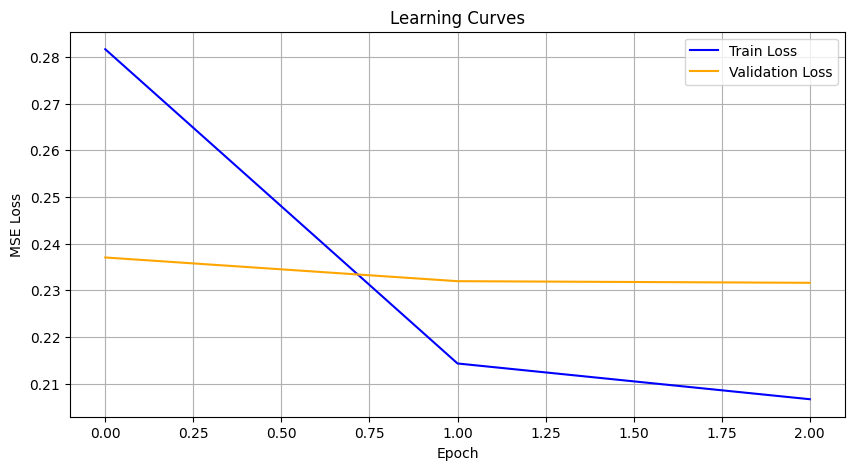

EPOCH 4/50
TRAIN - EPOCH 4/50 - loss: 0.2019890993833542
VALIDATION - EPOCH 4/50 - loss: 0.2321761134144378



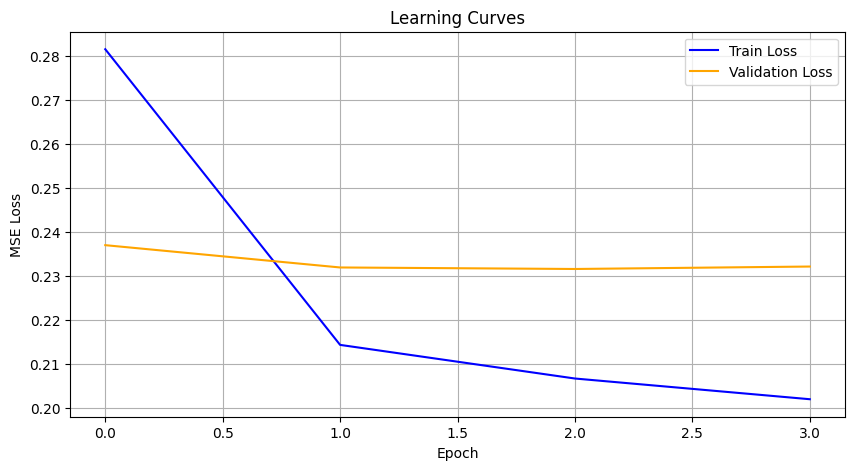

EPOCH 5/50
TRAIN - EPOCH 5/50 - loss: 0.1985902339220047
VALIDATION - EPOCH 5/50 - loss: 0.23239583906517725



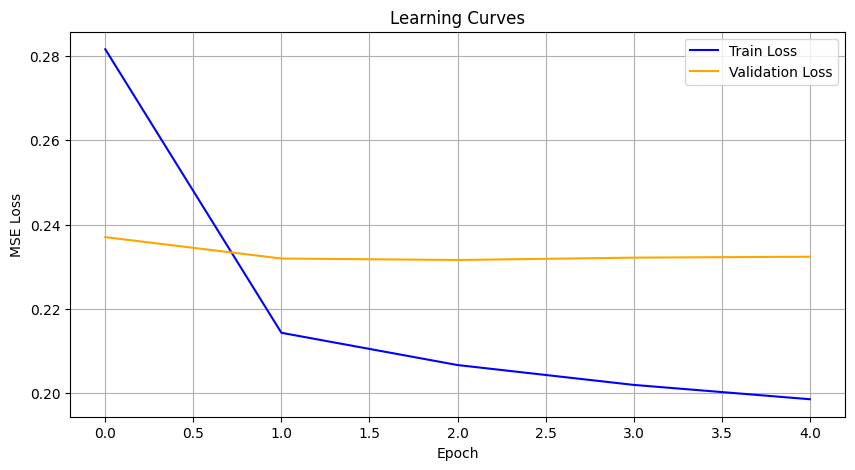

EPOCH 6/50
TRAIN - EPOCH 6/50 - loss: 0.19645965099334717
VALIDATION - EPOCH 6/50 - loss: 0.23221152238377699



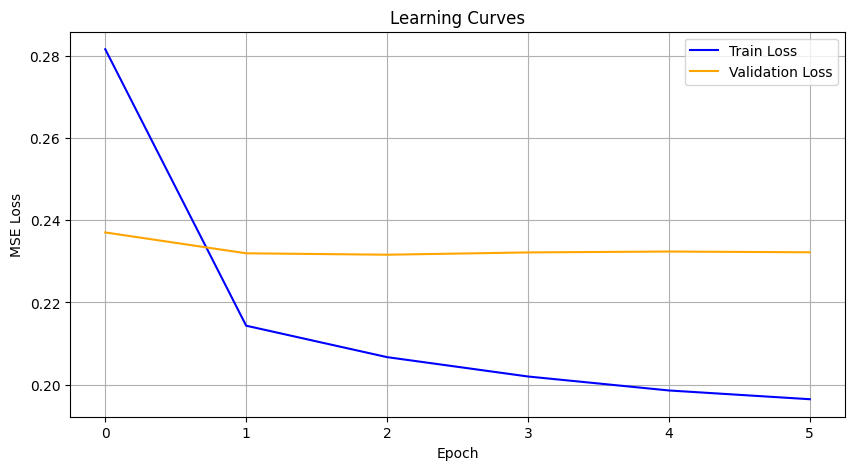

EPOCH 7/50
TRAIN - EPOCH 7/50 - loss: 0.19460347294807434
VALIDATION - EPOCH 7/50 - loss: 0.23346991830220507



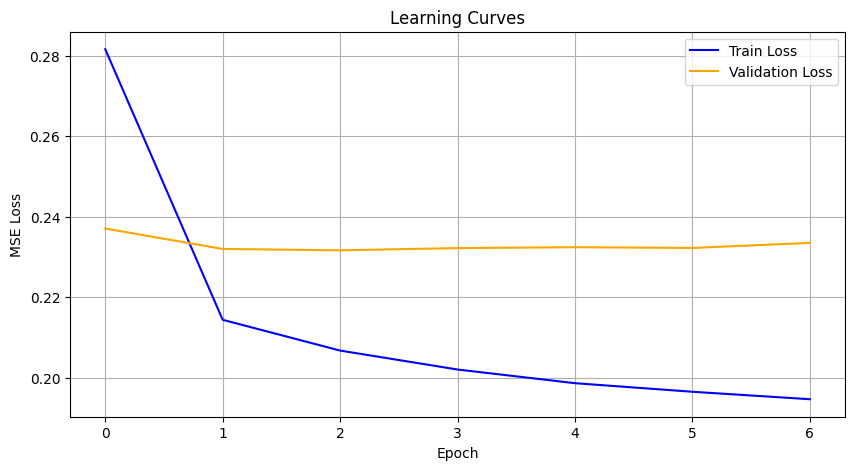

EPOCH 8/50
TRAIN - EPOCH 8/50 - loss: 0.19325022399425507
VALIDATION - EPOCH 8/50 - loss: 0.2370172515851722



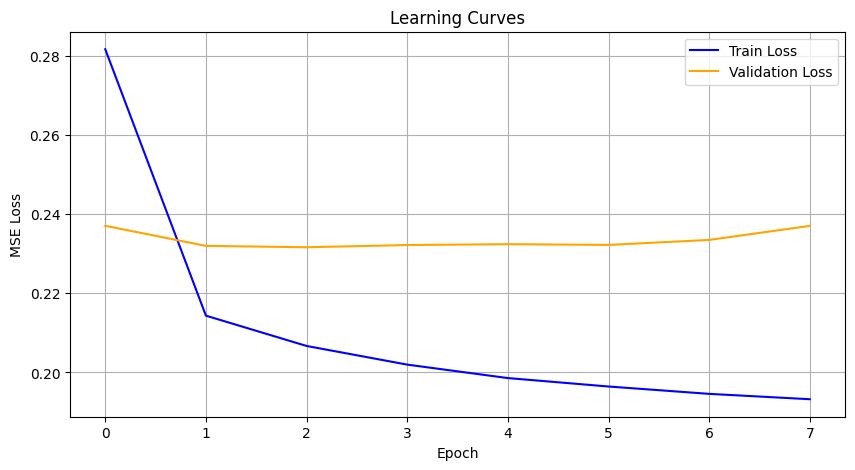

EPOCH 9/50


KeyboardInterrupt: 

In [15]:
num_epochs = 50
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    print('EPOCH %d/%d' % (epoch + 1, num_epochs))
    ### Training (use the training function)
    train_loss = train_epoch(
        encoder=image_encoder,
        decoder=image_decoder,
        device=device,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optim)
    print(f'TRAIN - EPOCH {epoch+1}/{num_epochs} - loss: {train_loss}')

    ### Validation  (use the testing function)
    val_loss = test_epoch(
        encoder=image_encoder,
        decoder=image_decoder,
        device=device,
        dataloader=val_loader,
        loss_fn=loss_fn)
    
    # Print Validation curves
    print(f'VALIDATION - EPOCH {epoch+1}/{num_epochs} - loss: {val_loss}\n')
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_history, label='Train Loss', color='blue')
    plt.plot(val_loss_history, label='Validation Loss', color='orange')
    plt.title('Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
